# 05 — Model Evaluation

Telco Customer Churn — Decision Trees & Ensemble Learning project

## 1. Learning Objectives

- Understand why accuracy alone can be a misleading metric
- Build a "dumb" baseline model and use it to prove that point with real numbers
- Explain precision, recall, F1-score, and ROC-AUC from first principles
- Read a confusion matrix and map TP/TN/FP/FN to real business outcomes
- Perform basic error analysis: look at *which* customers the model gets wrong

## 2. Business Problem

A model that's 90% "accurate" sounds great — until you learn it achieves
that by predicting "No Churn" for almost everyone, and churn only happens
26.5% of the time (notebook 01). This notebook is about learning to ask
**"accurate at what, exactly?"** before trusting any number.

## 3. Concept Explanation — The Confusion Matrix

### What is it?
For binary classification, every prediction falls into one of four buckets:

| | Predicted: No Churn | Predicted: Churn |
|---|---|---|
| **Actual: No Churn** | True Negative (TN) | False Positive (FP) |
| **Actual: Churn** | False Negative (FN) | True Positive (TP) |

### Mapped to our business problem
- **True Positive**: customer was going to churn, model correctly flagged them → retention team can act.
- **True Negative**: customer was going to stay, model correctly left them alone.
- **False Positive**: customer was going to stay, but model flagged them as a churn risk → wasted retention effort (e.g. an unnecessary discount offer).
- **False Negative**: customer was going to churn, but model predicted they'd stay → **the company loses the customer with no warning.** This is usually the most expensive mistake for a churn problem.

### Why do we need more than accuracy?
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

Accuracy treats all four buckets as equally important. But a False Negative
(losing a customer unexpectedly) is typically far costlier to the business
than a False Positive (an unnecessary retention offer) — accuracy alone
can't tell you which type of mistake a model is making.

## 4. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import RocCurveDisplay

from src.preprocessing.preprocessor import split_dataset, encode_categorical_features
from src.models.decision_tree_model import DecisionTreeModel
from src.evaluation.model_evaluator import evaluate_predictions

pd.set_option("display.max_columns", None)

## 5. Load Data

In [2]:
processed_data = pd.read_csv("../data/processed/processed_data.csv")
feature_columns = processed_data.drop(columns=["customerID", "Churn"]).columns
features = processed_data[feature_columns]
target = processed_data["Churn"]

training_features, testing_features, training_target, testing_target = split_dataset(features, target)
training_encoded, testing_encoded = encode_categorical_features(training_features, testing_features)
print("Test set churn rate: %.3f" % testing_target.mean())

2026-09-16 00:09:39 | INFO | src.preprocessing.preprocessor | Split dataset: 5634 training rows, 1409 testing rows (test_size=0.2)


2026-09-16 00:09:39 | INFO | src.preprocessing.preprocessor | One-hot encoding 15 categorical column(s)


Test set churn rate: 0.265


## 6. Class Imbalance — Why We Need a Baseline

### Concept
Before trusting any model's accuracy, ask: **"what accuracy would a trivial
model get?"** `DummyClassifier(strategy="most_frequent")` always predicts
the majority class ("No Churn") — it has learned literally nothing about
the features.

In [3]:
baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(training_encoded, training_target)

baseline_predictions = baseline_model.predict(testing_encoded)
baseline_metrics = evaluate_predictions(testing_target, baseline_predictions)

print("Baseline ('always predict No Churn') metrics:")
for metric_name, metric_value in baseline_metrics.to_dict().items():
    print(f"  {metric_name}: {metric_value:.3f}")

2026-09-16 00:09:39 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.735 precision=0.000 recall=0.000 f1=0.000 roc_auc=nan


Baseline ('always predict No Churn') metrics:
  accuracy: 0.735
  precision: 0.000
  recall: 0.000
  f1: 0.000
  roc_auc: nan


**What are we looking at?** The baseline gets ~73.5% accuracy — matching
the majority class proportion exactly, because it never predicts churn at
all. Notice its **recall is 0.0**: it catches zero actual churners, which
is the entire point of this project. High accuracy, completely useless
model — this is exactly why accuracy alone is a misleading metric here.

## 7. Train the Real Model and Compare

In [4]:
tree_model = DecisionTreeModel(criterion="gini", max_depth=5)
tree_model.fit(training_encoded, training_target)
tree_metrics = tree_model.evaluate(testing_encoded, testing_target)

comparison = pd.DataFrame({
    "baseline": baseline_metrics.to_dict(),
    "decision_tree": tree_metrics.to_dict(),
})
comparison

2026-09-16 00:09:39 | INFO | src.models.decision_tree_model | Initialized DecisionTreeModel(criterion=gini, max_depth=5, min_samples_split=2, min_samples_leaf=1)


2026-09-16 00:09:39 | INFO | src.models.decision_tree_model | Model trained on 5634 samples, 47 features


2026-09-16 00:09:39 | INFO | src.evaluation.model_evaluator | Evaluation - accuracy=0.798 precision=0.635 recall=0.567 f1=0.599 roc_auc=0.830


,baseline,decision_tree
accuracy,0.734564,0.798439
precision,0.000000,0.634731
recall,0.000000,0.566845
f1,0.000000,0.598870
roc_auc,NaN,0.830100


**Interpretation:** the decision tree trades a little bit of raw
accuracy improvement for a MASSIVE recall improvement (0.0 → well above
zero) — it actually catches churners, which the baseline cannot do at all.
This is the central lesson of this notebook: **always compare a real model
against a naive baseline**, and look beyond accuracy.

## 8. Precision, Recall, F1 — Formulas and Interpretation

$$Precision = \frac{TP}{TP + FP} \quad\quad Recall = \frac{TP}{TP + FN} \quad\quad F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

- **Precision**: "Of the customers we flagged as churn risks, how many
  actually churned?" High precision = few wasted retention offers.
- **Recall**: "Of the customers who actually churned, how many did we
  catch?" High recall = few surprise losses.
- **F1**: the harmonic mean of precision and recall — a single number that
  penalizes models which sacrifice one entirely for the other.

There is usually a **trade-off**: a model that flags almost everyone as a
churn risk gets high recall but low precision (many false alarms); a model
that only flags the most obvious cases gets high precision but low recall
(misses subtler churners).

## 9. Confusion Matrix — Visualized

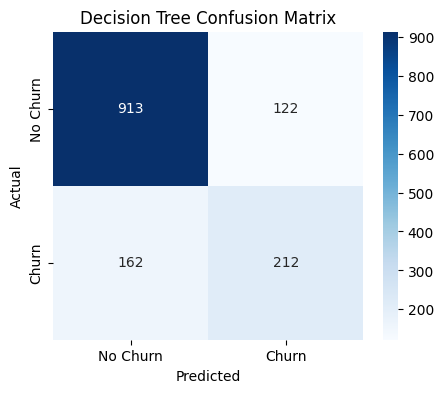

True Negatives:  913  (correctly predicted to stay)
False Positives: 122  (predicted churn, actually stayed)
False Negatives: 162  (predicted stay, ACTUALLY CHURNED — the costly mistake)
True Positives:  212  (correctly caught churners)


In [5]:
confusion = tree_metrics.confusion_matrix

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

true_negative, false_positive, false_negative, true_positive = confusion.ravel()
print(f"True Negatives:  {true_negative}  (correctly predicted to stay)")
print(f"False Positives: {false_positive}  (predicted churn, actually stayed)")
print(f"False Negatives: {false_negative}  (predicted stay, ACTUALLY CHURNED — the costly mistake)")
print(f"True Positives:  {true_positive}  (correctly caught churners)")

## 10. ROC-AUC

ROC-AUC summarizes how well the model ranks churners above non-churners
across every possible decision threshold — not just the default 0.5 cutoff
`predict()` uses. An AUC of 1.0 is a perfect ranker; 0.5 is no better than
random guessing.

<Figure size 600x600 with 0 Axes>

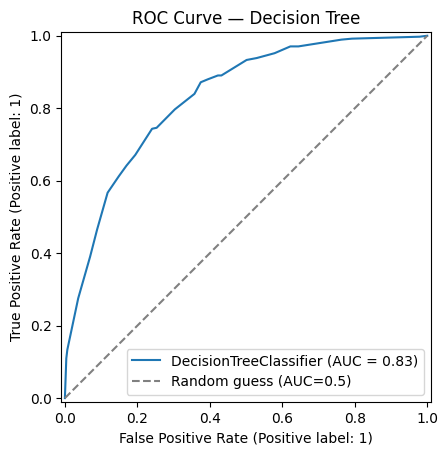

ROC-AUC: 0.830


In [6]:
plt.figure(figsize=(6, 6))
RocCurveDisplay.from_estimator(tree_model.classifier, testing_encoded, testing_target)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC=0.5)")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.show()

print(f"ROC-AUC: {tree_metrics.roc_auc:.3f}")

## 11. Error Analysis

Metrics summarize performance with a single number; error analysis looks at
**which specific customers** the model gets wrong, and whether there's a
pattern to the mistakes.

In [7]:
predicted_labels = tree_model.predict(testing_encoded)
predicted_probabilities = tree_model.predict_proba(testing_encoded)[:, 1]

error_analysis_df = testing_features.copy()
error_analysis_df["actual"] = testing_target.values
error_analysis_df["predicted"] = predicted_labels
error_analysis_df["prediction_probability"] = predicted_probabilities.round(3)

false_negatives_df = error_analysis_df[
    (error_analysis_df["actual"] == 1) & (error_analysis_df["predicted"] == 0)
]
print(f"False negatives (missed churners): {len(false_negatives_df)}")
false_negatives_df[["tenure", "MonthlyCharges", "Contract", "prediction_probability"]].head(10)

False negatives (missed churners): 162


,tenure,MonthlyCharges,Contract,prediction_probability
1639,17,45.05,Month-to-month,0.385
2488,31,55.25,Month-to-month,0.385
523,23,75.60,Month-to-month,0.371
5086,45,20.40,One year,0.028
3408,4,50.70,Month-to-month,0.209
7011,4,60.40,Month-to-month,0.116
3158,18,49.55,Month-to-month,0.209
5968,12,74.05,One year,0.255
1577,17,98.60,One year,0.226
3975,20,85.80,Month-to-month,0.371


### What types of customers does the model get wrong?

In [8]:
print("Missed churners — median tenure:", false_negatives_df["tenure"].median())
print("All churners in test set — median tenure:",
      error_analysis_df.loc[error_analysis_df["actual"] == 1, "tenure"].median())
print()
print("Missed churners — Contract distribution:")
print(false_negatives_df["Contract"].value_counts(normalize=True).round(2))

Missed churners — median tenure: 24.0
All churners in test set — median tenure: 8.0

Missed churners — Contract distribution:
Contract
Month-to-month    0.72
One year          0.22
Two year          0.06
Name: proportion, dtype: float64


**Interpretation:** compare the missed churners' typical tenure and
contract type against churners the model *did* catch. If missed churners
tend to have longer tenure than caught churners, it suggests the model has
over-learned "long tenure = safe," missing longer-tenured customers who
churn for reasons the model hasn't captured (e.g. a price increase, a
competitor offer) — exactly the kind of insight a single accuracy number
would never reveal.

## 12. Common Mistakes

- **Reporting only accuracy** for an imbalanced problem — always check
  against a baseline first (section 6).
- **Optimizing purely for precision or purely for recall** without
  considering the business cost of each error type (section 3).
- **Using the default 0.5 probability threshold** without considering
  whether a different threshold better matches the cost of False Negatives
  vs. False Positives for this specific business problem.
- **Stopping at the confusion matrix** without ever looking at *which*
  individual rows were misclassified (section 11) — the aggregate numbers
  can hide a systematic blind spot.

## 13. What We Learned

- A trivial baseline can achieve high accuracy on this dataset by exploiting
  class imbalance while catching zero churners (recall = 0).
- Precision and recall reveal a trade-off that accuracy alone hides.
- False Negatives (missed churners) are usually the costliest error type
  for this business problem, even though they don't look "worse" in a raw
  accuracy count.
- Error analysis on individual misclassified rows can reveal patterns a
  single metric can't.

## 14. Exercises

1. Compute precision and recall by hand from the confusion matrix numbers
   printed in section 9, using the formulas in section 8. Confirm they match
   `tree_metrics.to_dict()`.
2. `DummyClassifier(strategy="stratified")` predicts randomly, matching the
   training class proportions. Try it — how does its recall compare to
   `"most_frequent"`? Why is it still a bad model despite non-zero recall?
3. Look at the False Positives instead of False Negatives in section 11.
   Do they share any pattern with the correctly-caught churners?
4. If your business priority were "minimize wasted retention offers" instead
   of "catch every churner," would you optimize for precision or recall?
   Explain in one sentence.

## Interview Questions

1. Why is accuracy a poor metric for imbalanced classification problems?
   Give a concrete example using numbers from this notebook.
2. In a medical diagnosis context, would you prioritize precision or recall?
   How does that compare to this churn problem, and why might the answer differ?
3. What does an ROC-AUC of exactly 0.5 tell you about a model?